# Master MIND - IDLE

# Réseaux convolutionnels

------------------------------------------------------------------------

**Remarque:** Si vous arrivez ici sans avoir lu les instructions
d’installation sur la page du cours, ça ne va pas marcher. Goto
<https://schwander.isir.upmc.fr/enseignement/m1mind_idle/> dans ce cas.

In [1]:
import torch
from torch import nn, optim
from tqdm import trange
from torch.functional import F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Exercice 1 - *Dataset* *CIFAR10*

On va utiliser le dataset
[CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html), un petit dataset
(60000 exemples) d’images RGB de taille 32x32 (remarque: en cas de souci
de temps de calcul, on peut travailler sur un sous-ensemble, par exemple
10% des données).

![](attachment:tp-cnn/cifar10.png)

## Question 1 - *Chargement*

Charger le dataset en utilisant la fonction fournie par PyTorch
<https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html>

In [228]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5,0.5,0.5))
])

batch_size = 1000
train_set = datasets.CIFAR10("./data",
                            train=True, 
                            download=True,
                            transform=transform)
test_set = datasets.CIFAR10("./data",
                        train=False, 
                        download=True,
                        transform=transform)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=True)

classes = train_set.classes

/Users/vlad/Documents/University/Master-MIND/M1-S2-MIND/IDLE/tme/tme03/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Question 2 - *Exploration* *préliminaire*

Avec le module `pandas` ou `polars`, analyser rapidement le contenu du
dataset.

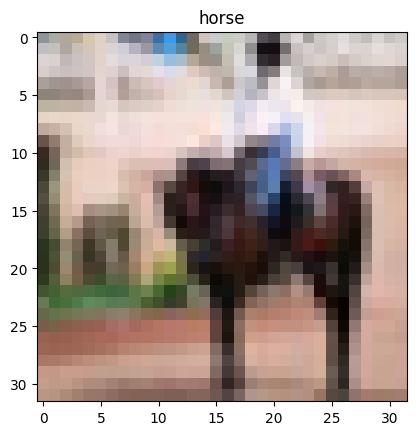

In [3]:
i = 11
plt.imshow(train_set.data[i])
plt.title(classes[train_set.targets[i]]);

# Exercice 2 - *Architecture*

## Question 3 - *Baseline*

Construire et évaluer un MLP pour cette tâche.

On veillera à tracer et à analyser les courbes d’apprentissage.

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1) # flatten
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [229]:
model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

losses = []
train_scores = []
test_scores = []
max_iter = 10
for epoch in trange(max_iter):
    model.train()
    epoch_loss = 0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs,batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_x.size(0) 

    epoch_loss /= len(train_loader.dataset) 
    losses.append(epoch_loss)
    
    train_scores.append((outputs.argmax(1)==batch_y).sum().item() / batch_y.size(0))
    model.eval()
    total = correct = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            outputs = model(batch_x)
            predicted = outputs.argmax(1)
            total += batch_y.size(0)
            correct += (predicted==batch_y).sum().item()
        test_scores.append(correct/total)


100%|██████████| 10/10 [00:27<00:00,  2.73s/it]


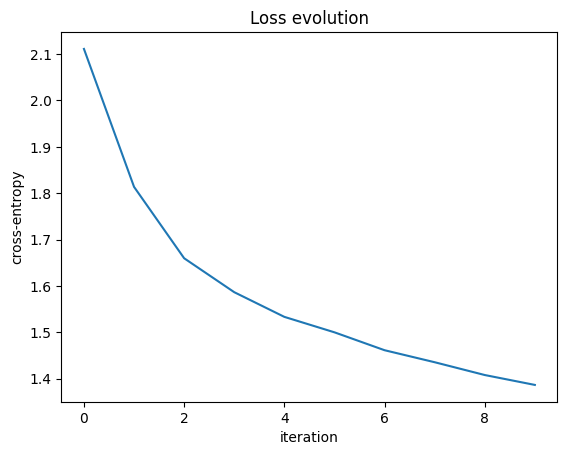

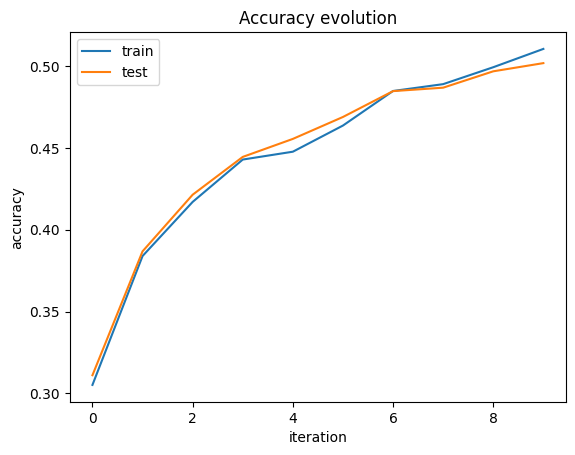

In [309]:
plt.plot(range(len(losses)), losses)
plt.title("Loss evolution")
plt.ylabel("cross-entropy")
plt.xlabel("iteration")
plt.show()

plt.plot(range(len(train_scores)), train_scores, label="train")
plt.plot(range(len(test_scores)), test_scores
, label="test")
plt.legend()
plt.title("Accuracy evolution")
plt.ylabel("accuracy")
plt.xlabel("iteration")
plt.show()

## Question 4 - *CNN*

Construire et évaluer un petit CNN (2 couches de convolution). On fera
en sorte que le nombre de couches soit un hyper-paramètre.

*On veillera à tracer et à analyser les courbes d’apprentissage.*

In [294]:
class CNN(nn.Module):
    def __init__(self, n_layers) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5) 
        self.conv2 = nn.Conv2d(6,16,5) 

        self.convs = nn.ModuleList(
            [nn.Conv2d(3,6,5)] + 
            [nn.Conv2d(6,6,5) for _ in range(n_layers-1)]
            )

        self.pool = nn.MaxPool2d(2,2) 

        # compute output size after conv + pool
        dummy = torch.zeros(1, 3, 32, 32)
        x = dummy
        for conv in self.convs:
            x = self.pool(F.relu(conv(x)))
        conv_out_size = x.numel()
        
        self.fc1 = nn.Linear(conv_out_size, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        self.act_maps = []
    
    def forward(self, x):
        self.act_maps = []

        for conv in self.convs:
            x = F.relu(conv(x))
            self.act_maps.append(x)
            x = self.pool(x)

        x = torch.flatten(x,1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) 
        # don't apply softmax, it's integrated in CE
        return x
    
cnn = CNN(n_layers=2)


In [295]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=0.001)

In [296]:
losses = []
train_scores = []
test_scores = []

max_iter = 10
for epoch in trange(max_iter):
    epoch_loss = 0.0
    for inputs, labels in train_loader:    
        optimizer.zero_grad()
        outputs = cnn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * inputs.size(0) 

    epoch_loss /= len(train_loader.dataset) 
    losses.append(epoch_loss)
    
    with torch.no_grad():
        correct, total = 0, 0
        for batch_x, batch_y in train_loader:
            outputs = cnn(batch_x)
            predicted = outputs.argmax(-1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
        train_scores.append(correct/total)
        correct, total = 0, 0
        for batch_x, batch_y in test_loader:
            outputs = cnn(batch_x)
            predicted = outputs.argmax(-1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
        test_scores.append(correct/total)
PATH = './cifar_cnn.pth'
torch.save(cnn.state_dict(), PATH)

100%|██████████| 10/10 [01:39<00:00,  9.97s/it]


In [299]:
cnn = CNN(2)
cnn.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

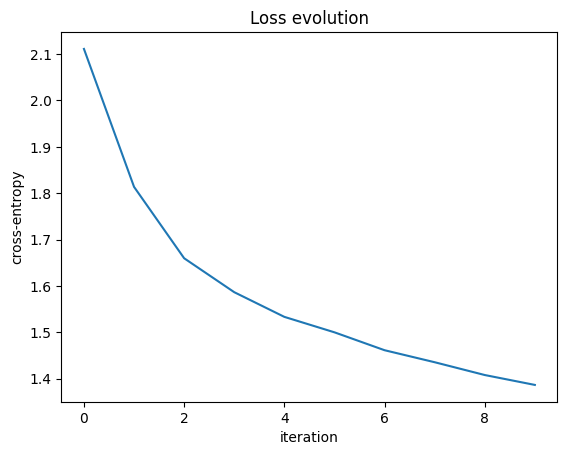

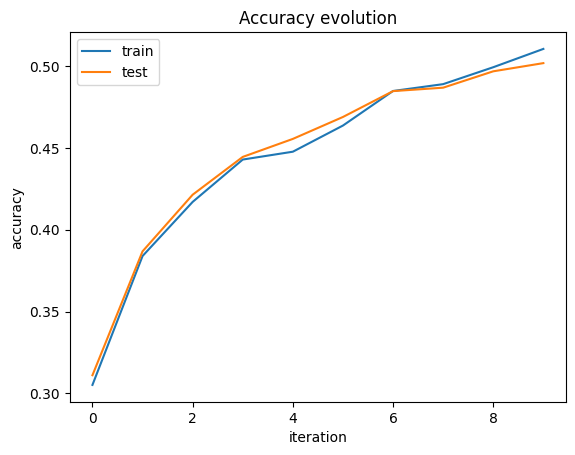

In [300]:
plt.plot(range(len(losses)), losses)
plt.title("Loss evolution")
plt.ylabel("cross-entropy")
plt.xlabel("iteration")
plt.show()

plt.plot(range(len(train_scores)), train_scores, label="train")
plt.plot(range(len(test_scores)), test_scores
, label="test")
plt.legend()
plt.title("Accuracy evolution")
plt.ylabel("accuracy")
plt.xlabel("iteration")
plt.show()

In [301]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        outputs = cnn(images)
        _, predictions = torch.max(outputs, 1)

        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'{classname:5s}: {accuracy:.1f} %')

airplane: 50.6 %
automobile: 59.5 %
bird : 39.1 %
cat  : 37.5 %
deer : 32.2 %
dog  : 35.3 %
frog : 63.5 %
horse: 60.0 %
ship : 68.1 %
truck: 56.0 %


## Question 5 - *Hyper-paramètres*

Réaliser une petite exploration des hyper-paramètres (notamment le
nombre de couches).

**On veillera à tracer et à analyser les courbes d’apprentissage.**

In [ ]:
# TODO

## Question 6 - *Courbes* *d’apprentissage*

En changeant la taille du réseau, la quantité de données ou d’autres
hyper-paramètres, faire apparaître sur les courbes d’apprentissage les
cas suivants:

-   sous-apprentissage
-   sur-apprentissage
-   optimisation ratée

In [ ]:
# TODO

# Exercice 3 - *Interprétation*

## Question 7 - *Cartes* *d’activation*

En manipulant l’implémation de l’architecutre, récupérer les cartes
d’activations finales.

En inférence, visualiser et analyser ces cartes.

Conclure sur le comportement du réseau.

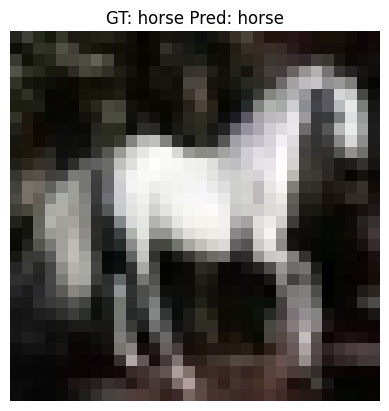

In [302]:
i = 13
plt.imshow(test_set.data[i])
input = torch.tensor(np.transpose(test_set.data[i], (2,0,1)), dtype=torch.float32).unsqueeze(0)
plt.title(f"GT: {classes[test_set.targets[i]]} Pred: {classes[cnn(input).argmax()]}")
plt.axis("off")
plt.show()

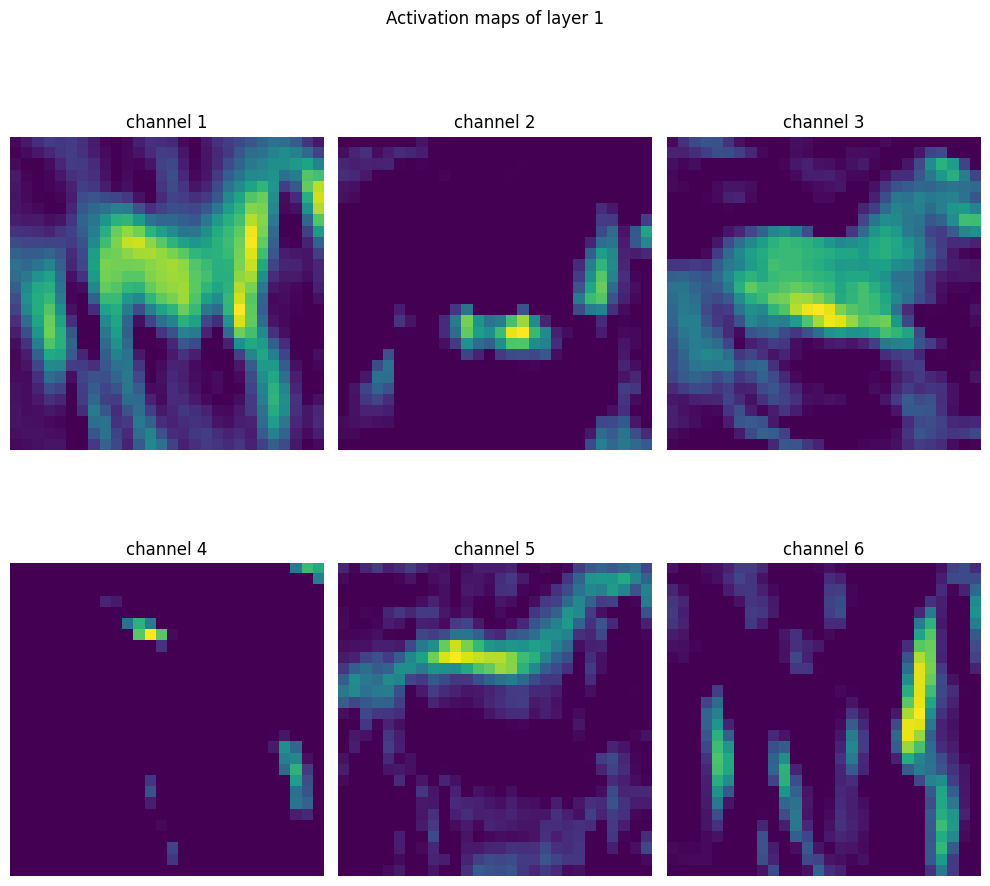

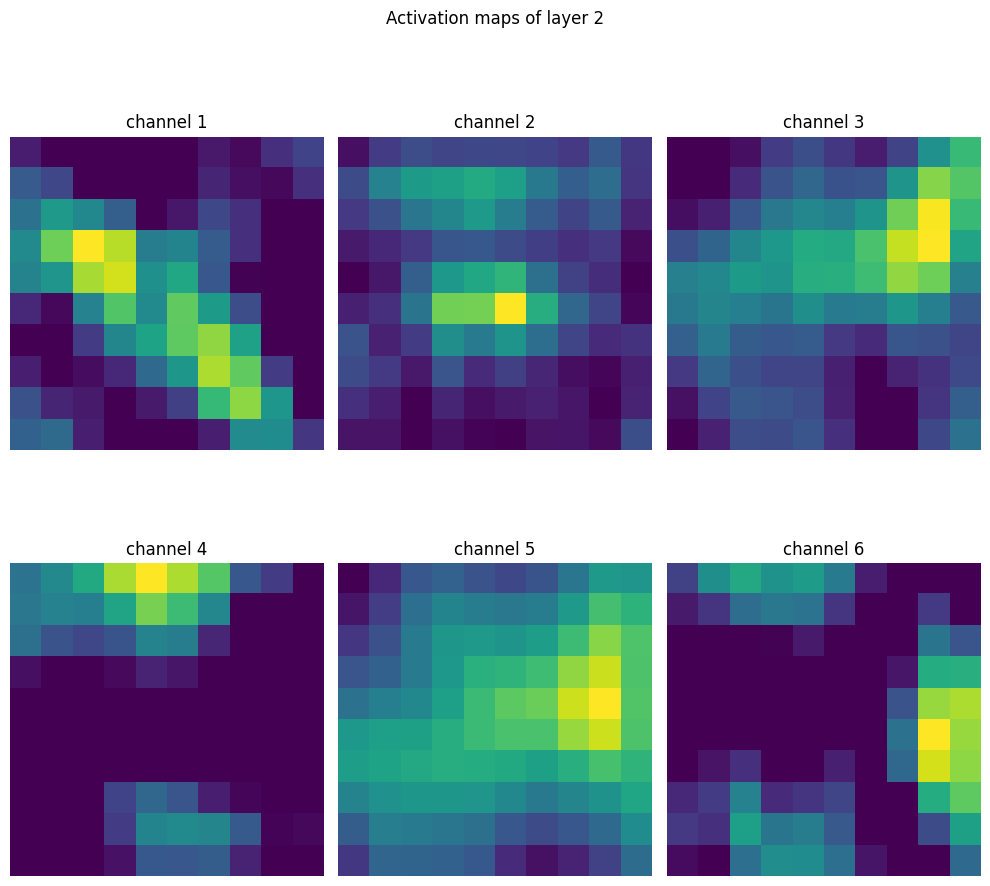

In [308]:
for l, act_maps in enumerate(cnn.act_maps):
    act_maps = act_maps.squeeze().detach().numpy()

    num_maps = act_maps.shape[0]
    cols = 3
    rows = (num_maps + 1) // cols  

    fig, axes = plt.subplots(rows, cols, figsize=(10, rows*5))  
    axes = axes.flatten() 

    for i, act_map in enumerate(act_maps):
        axes[i].imshow(act_map, cmap='viridis') 
        axes[i].axis('off')  
        axes[i].set_title(f"channel {i+1}")

    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f"Activation maps of layer {l+1}")
    plt.tight_layout()
    plt.show()